# Módulo 4 — Calibración del modelo de precio (AR(1) sobre retornos log)
## Índice de precio del pistacho (PPI, FRED) — Jocolí, Mendoza

Diagnóstico de autocorrelación y calibración del AR(1) sobre retornos logarítmicos,
documentado acá para citar directo en el capítulo metodológico de la tesis (ver
`notas/plan_precio_historico.md`, Paso 3).

In [1]:
import subprocess
import sys
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    REPO_URL = "https://github.com/Emilialandgrebe/tesis-maestria.git"
    ROOT = Path("/content/tesis-maestria")
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(ROOT / "requirements.txt"), "-q"],
        check=True,
    )
else:
    ROOT = Path().resolve().parent  # notebooks/ -> raiz del proyecto

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Entorno : {'Google Colab' if EN_COLAB else 'local'}")
print(f"ROOT    : {ROOT}")

Entorno : local
ROOT    : C:\Users\EMILIA LANDGREBE\tesis-maestria


## Por qué reemplazar el precio triangular independiente

`simulate_prices()` sortea el precio de cada año de forma independiente, con una
distribución triangular por escenario (pesimista / base / optimista) sin memoria
entre años. Eso descarta por construcción cualquier autocorrelación real del precio
del pistacho.

Se evaluaron dos alternativas calibradas con datos reales del precio (FRED, serie
`WPU01190106`, PPI mensual, BLS, 1991-2026):

- **GBM puro (retornos i.i.d.):** el test ADF sobre el *nivel* de precio no rechaza
  raíz unitaria, lo que en principio sería compatible con un random walk. Pero
  componer 20 años de volatilidad sin ninguna corrección produce colas
  económicamente implausibles (P90 del precio en el año 20 ≈ USD 50+/kg en el
  escenario optimista, muy por encima de cualquier máximo histórico real).
- **AR(1) sobre los retornos logarítmicos** (no sobre el nivel de precio — la
  distinción importa: un AR(1) sobre el *nivel* es un proceso de reversión a la
  media tipo Ornstein-Uhlenbeck, mientras que un AR(1) sobre los *retornos* deja
  que el nivel de precio no tenga reversión — solo sus variaciones tienen
  memoria). Esta es la alternativa elegida para el proyecto.

La justificación no se apoya solo en la significancia estadística del coeficiente
AR(1) (marginal, con un N chico de datos anuales reales), sino en la sensibilidad
de la aplicación —la composición a 20 años— al supuesto de independencia de los
retornos: aunque el coeficiente no sea significativo al 5%, ignorarlo tiene
consecuencias económicas grandes en un horizonte de 20 años.

Cargando datos locales desde C:\Users\EMILIA LANDGREBE\tesis-maestria\data\raw\precio_pistacho_fred.parquet


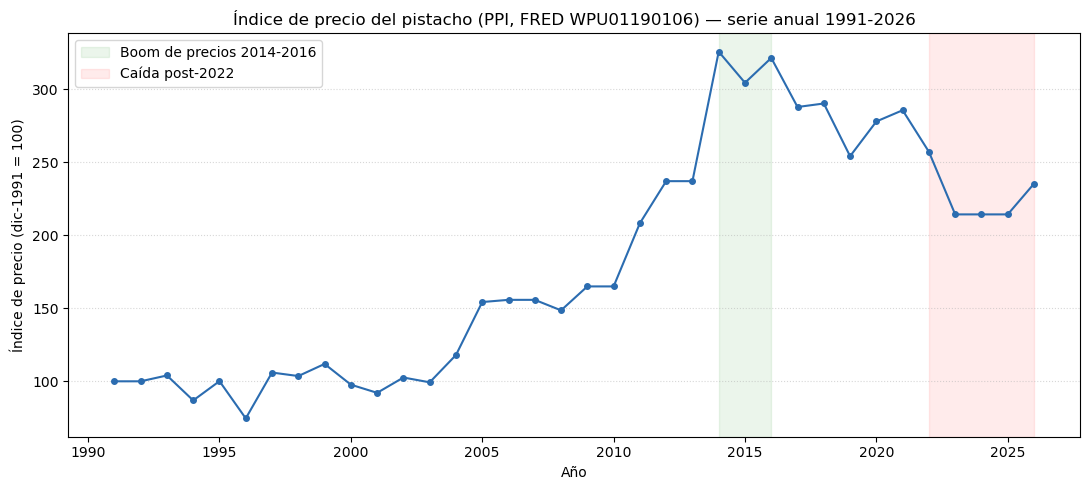

año
1991    100.000
1992    100.000
1993    104.000
1994     86.900
1995    100.100
1996     74.600
1997    106.000
1998    103.600
1999    111.900
2000     97.700
2001     92.100
2002    102.600
2003     99.300
2004    118.000
2005    154.300
2006    155.800
2007    155.800
2008    148.600
2009    165.000
2010    165.000
2011    208.300
2012    237.100
2013    237.100
2014    325.800
2015    304.500
2016    321.500
2017    287.900
2018    290.300
2019    254.200
2020    278.000
2021    285.683
2022    257.201
2023    214.334
2024    214.334
2025    214.334
2026    235.367
Name: indice_precio, dtype: float64

In [2]:
import matplotlib.pyplot as plt

from src.data.price_fetcher import fetch_price_data
from src.data.price_features import calcular_serie_anual

df_mensual = fetch_price_data()
serie_anual = calcular_serie_anual(df_mensual)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie_anual.index, serie_anual.values, marker="o", markersize=4, color="#2b6cb0")
ax.axvspan(2014, 2016, color="green", alpha=0.08, label="Boom de precios 2014-2016")
ax.axvspan(2022, 2026, color="red", alpha=0.08, label="Caída post-2022")
ax.set_title("Índice de precio del pistacho (PPI, FRED WPU01190106) — serie anual 1991-2026")
ax.set_xlabel("Año")
ax.set_ylabel("Índice de precio (dic-1991 = 100)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

serie_anual

In [3]:
from src.data.price_features import diagnosticar_autocorrelacion

diagnostico = diagnosticar_autocorrelacion(serie_anual)
diagnostico

DiagnosticoAutocorrelacion(n_obs=35, acf_lag1=-0.263547626036078, ljung_box_pvalor_lag1=0.10384296189117433, adf_estadistico=-1.0715265230193074, adf_pvalor=0.7262922306902857, ar1_phi=-0.26542335902397685, ar1_pvalor=0.13051578803769273, conclusion='El ADF no rechaza raíz unitaria en el nivel (p=0.726) y el AR(1) no es significativo al 5% (p=0.131), pero phi=-0.2654 es económicamente relevante por el efecto de composición a 20 años (ver notas/plan_precio_historico.md) — no se descarta autocorrelación solo por falta de significancia estadística con N chico.')

## Conclusión del diagnóstico (para citar en la tesis)

Texto tal cual generado por `diagnosticar_autocorrelacion(serie_anual).conclusion`
sobre la serie completa 1991-2026 (`n_obs=35` retornos anuales, confirmado en el
commit `b4a0889`):

> El ADF no rechaza raíz unitaria en el nivel (p=0.726) y el AR(1) no es
> significativo al 5% (p=0.131), pero phi=-0.2654 es económicamente relevante por
> el efecto de composición a 20 años (ver notas/plan_precio_historico.md) — no se
> descarta autocorrelación solo por falta de significancia estadística con N chico.

In [4]:
import pandas as pd

from src.data.price_features import calibrar_ar1

parametros_ar1 = calibrar_ar1(serie_anual)

print(f"Período : {parametros_ar1.periodo}")
print(f"n_obs   : {parametros_ar1.n_obs}")

pd.DataFrame(
    {
        "parámetro": ["c", "phi", "sigma_eps"],
        "valor": [parametros_ar1.c, parametros_ar1.phi, parametros_ar1.sigma_eps],
    }
).set_index("parámetro")

Período : 1991-2026
n_obs   : 34


,valor
parámetro,
c,0.031127
phi,-0.265423
sigma_eps,0.137358
